In [1]:
import os
import sys
import shutil
import glob

# --- COLAB SETUP ---
try:
    from google.colab import drive
    IN_COLAB = True
    print("Running in Google Colab")

    drive.mount('/content/drive')

    REPO_URL = "https://github.com/zeynepoztunc/aml-procedural-mistake-detection.git"
    BRANCH = "emre-second-step"

    if not os.path.exists('/content/code'):
        !git clone --recursive {REPO_URL} /content/code
        os.chdir('/content/code')
        !git fetch origin {BRANCH}
        !git checkout {BRANCH}
    else:
        os.chdir('/content/code')
        !git fetch origin {BRANCH}
        !git checkout {BRANCH}
        !git pull origin {BRANCH}

    if '/content/code' not in sys.path:
        sys.path.append('/content/code')

    # Install PyTorch Geometric
    !pip install -q torch-geometric

    # --- DATA SETUP ---
    DRIVE_BASE = "/content/drive/MyDrive/AML_Project"

    # Extract annotations from 1s.zip if needed
    data_zip = f"{DRIVE_BASE}/1s.zip"
    if not os.path.exists("annotations/annotation_json/step_annotations.json"):
        if os.path.exists(data_zip):
            print("Extracting annotations from 1s.zip...")
            !mkdir -p data
            !unzip -q -n "{data_zip}" -d data
            if os.path.exists("data/1s/annotations"):
                !cp -r data/1s/annotations .
            if os.path.exists("data/1s"):
                !rm -rf data/1s
            print("Annotations extracted.")

    # Copy step3 output from Drive if exists
    os.makedirs("extension_data", exist_ok=True)
    DRIVE_STEP3_OUTPUT = f"{DRIVE_BASE}/extension_data/realized_task_graphs.pkl"
    LOCAL_STEP3_OUTPUT = "extension_data/realized_task_graphs.pkl"

    if os.path.exists(DRIVE_STEP3_OUTPUT) and not os.path.exists(LOCAL_STEP3_OUTPUT):
        print("Copying step3 output from Drive...")
        !cp "{DRIVE_STEP3_OUTPUT}" "{LOCAL_STEP3_OUTPUT}"
        print("Done!")
    elif os.path.exists(LOCAL_STEP3_OUTPUT):
        print("Step3 output already exists locally.")
    else:
        print("WARNING: Step3 output not found. Run extension_step3 first!")

except ImportError:
    IN_COLAB = False
    print("Not running in Colab")

Running in Google Colab
Mounted at /content/drive
Cloning into '/content/code'...
remote: Enumerating objects: 883, done.
remote: Counting objects: 100% (133/133), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 883 (delta 104), reused 93 (delta 88), pack-reused 750 (from 1)
Receiving objects: 100% (883/883), 96.49 MiB | 50.75 MiB/s, done.
Resolving deltas: 100% (478/478), done.
Submodule 'annotations' (https://github.com/CaptainCook4D/annotations) registered for path 'annotations'
Cloning into '/content/code/annotations'...
remote: Enumerating objects: 152, done.        
remote: Counting objects: 100% (152/152), done.        
remote: Compressing objects: 100% (98/98), done.        
remote: Total 152 (delta 75), reused 108 (delta 46), pack-reused 0 (from 0)        
Receiving objects: 100% (152/152), 793.14 KiB | 14.42 MiB/s, done.
Resolving deltas: 100% (75/75), done.
Submodule path 'annotations': checked out '0e9a108be2cbcbcbd592e7418c0ab9c16232d27a'
From https://

In [2]:
import pickle
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, balanced_accuracy_score)
from collections import defaultdict
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Import PyTorch Geometric
try:
    from torch_geometric.data import Data, Batch
    from torch_geometric.nn import GCNConv, GATConv, SAGEConv, global_mean_pool, global_max_pool
    from torch_geometric.loader import DataLoader as PyGDataLoader
    PYG_AVAILABLE = True
    print("PyTorch Geometric loaded successfully")
except ImportError:
    PYG_AVAILABLE = False
    print("PyTorch Geometric not available. Using simple baseline only.")

PyTorch Geometric loaded successfully


## 1. Load Realized Task Graphs

In [4]:
# Load realized graphs from Substep 3
DATA_PATH = "extension_data/realized_task_graphs.pkl"

if IN_COLAB:
    DRIVE_DATA_PATH = "/content/drive/MyDrive/AML_Project/extension_data/realized_task_graphs.pkl"
    if os.path.exists(DRIVE_DATA_PATH):
        DATA_PATH = DRIVE_DATA_PATH

if os.path.exists(DATA_PATH):
    with open(DATA_PATH, 'rb') as f:
        loaded_data = pickle.load(f)

    realized_graphs = loaded_data['realized_graphs']
    splits = loaded_data['splits']
    config = loaded_data['config']

    print(f"Loaded {len(realized_graphs)} realized graphs")
    print(f"Feature dimension: {config['feature_dim']}")
else:
    print(f"Data not found at {DATA_PATH}")
    print("Please run extension_step3_task_graph_matching.ipynb first!")

Loaded 383 realized graphs
Feature dimension: 256


In [5]:
FEATURE_DIM = config['feature_dim']

# Substep 3 stores the text and visual node features separately so the projection can
# be learned here. Fail loudly rather than silently falling back to the old format.
_sample = next(iter(realized_graphs.values()))
_required = ['node_text_features', 'node_visual_features', 'node_features', 'node_matched']
_missing = [k for k in _required if k not in _sample]
assert not _missing, (
    f"realized_task_graphs.pkl is missing {_missing}. It was produced by an older "
    f"Substep 3. Re-run extension_step3_task_graph_matching.ipynb to regenerate it."
)

# Node input to the model is [visual | text | matched_flag]; the combiner inside each
# model maps that back down to FEATURE_DIM.
NODE_INPUT_DIM = 2 * FEATURE_DIM + 1
print(f"Feature dim: {FEATURE_DIM}, raw node input dim: {NODE_INPUT_DIM}")

# Group by recipe type
recipe_groups = defaultdict(list)
for recording_id, graph in realized_graphs.items():
    recipe_groups[graph['recipe_id']].append(recording_id)

print(f"Number of recipe types: {len(recipe_groups)}")

num_nodes_list = [g['num_nodes'] for g in realized_graphs.values()]
labels = [g['recipe_label'] for g in realized_graphs.values()]
print(f"Average nodes per graph: {np.mean(num_nodes_list):.1f}")
print(f"Label distribution: {sum(labels)} incorrect, {len(labels)-sum(labels)} correct")
print(f"Majority-class rate: {max(sum(labels), len(labels)-sum(labels))/len(labels):.2%}")

Feature dim: 256, raw node input dim: 513
Number of recipe types: 24
Average nodes per graph: 14.6
Label distribution: 219 incorrect, 164 correct
Majority-class rate: 57.18%


## 2. Create PyG Data Objects

In [6]:
def create_pyg_data(realized_graph, recording_id):
    """
    Convert a realized graph to a PyTorch Geometric Data object.

    Node features are stacked as [visual | text | matched_flag] rather than pre-combined.
    The combiner module inside each model turns that into the node representation, which
    is what lets the spec's projection be *learned* from the classification loss instead
    of being a fixed average fixed at graph-construction time.
    """
    visual = np.asarray(realized_graph['node_visual_features'], dtype=np.float32)
    text = np.asarray(realized_graph['node_text_features'], dtype=np.float32)
    matched = np.asarray(realized_graph['node_matched'], dtype=np.float32).reshape(-1, 1)

    x = torch.FloatTensor(np.concatenate([visual, text, matched], axis=1))

    # Edge index (make undirected by adding reverse edges)
    edge_index = realized_graph['edge_index']
    if edge_index.shape[1] > 0:
        reverse_edges = np.array([edge_index[1], edge_index[0]])
        edge_index = np.concatenate([edge_index, reverse_edges], axis=1)
    edge_index = torch.LongTensor(edge_index)

    y = torch.FloatTensor([realized_graph['recipe_label']])

    node_matched = torch.FloatTensor(realized_graph['node_matched'].astype(float))
    match_sims = torch.FloatTensor(realized_graph['match_similarities'])

    data = Data(
        x=x,
        edge_index=edge_index,
        y=y,
        node_matched=node_matched,
        match_sims=match_sims,
        recording_id=recording_id,
        recipe_id=realized_graph['recipe_id']
    )

    return data

if PYG_AVAILABLE:
    pyg_data = {}
    for recording_id, graph in realized_graphs.items():
        pyg_data[recording_id] = create_pyg_data(graph, recording_id)

    print(f"Created {len(pyg_data)} PyG Data objects")

    sample = list(pyg_data.values())[0]
    print(f"\nSample graph:")
    print(f"  Nodes: {sample.x.shape}  (expected [n, {2 * FEATURE_DIM + 1}])")
    print(f"  Edges: {sample.edge_index.shape}")
    print(f"  Label: {sample.y.item()}")
    assert sample.x.shape[1] == NODE_INPUT_DIM

Created 383 PyG Data objects

Sample graph:
  Nodes: torch.Size([12, 513])  (expected [n, 513])
  Edges: torch.Size([2, 22])
  Label: 0.0


## 3. Define GNN Models

In [7]:
# ==============================================================================
# Node feature combiners
# ==============================================================================
# The spec for Substep 3 says: "update the features of the matched nodes with a
# learnable projection of the node features and the visual features."
#
# The projection lives here, not in Substep 3, because it can only be *learned* where
# there is a loss to train it. Substep 3 has no objective, so a projector instantiated
# there would apply a fixed random transform. Here it is the first module of the GNN and
# is trained end-to-end by the graph classification loss.
#
# Both combiners take the same raw node input [visual | text | matched_flag] so the two
# can be compared as a clean ablation on identical data and folds.

class LearnableProjection(nn.Module):
    """The spec's learnable projection of node (text) features and visual features."""

    def __init__(self, feature_dim, hidden_dim=256):
        super().__init__()
        self.feature_dim = feature_dim
        self.proj = nn.Sequential(
            nn.Linear(feature_dim * 2 + 1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, feature_dim),
            nn.LayerNorm(feature_dim)
        )

    def forward(self, x):
        return self.proj(x)


class FixedAverage(nn.Module):
    """No-projection baseline, reproducing Substep 3's `node_features` exactly.

    Matched nodes get 0.5*visual + 0.5*text; unmatched nodes keep their text embedding
    (their visual slot is all zeros, so the matched flag is what selects between them).
    Has no parameters, so any gap against LearnableProjection is attributable to the
    projection itself rather than to extra capacity elsewhere.
    """

    def __init__(self, feature_dim):
        super().__init__()
        self.feature_dim = feature_dim

    def forward(self, x):
        d = self.feature_dim
        visual, text, matched = x[:, :d], x[:, d:2 * d], x[:, 2 * d:2 * d + 1]
        return matched * (0.5 * visual + 0.5 * text) + (1.0 - matched) * text


def make_combiner(kind, feature_dim, hidden_dim=256):
    if kind == 'projection':
        return LearnableProjection(feature_dim, hidden_dim)
    if kind == 'average':
        return FixedAverage(feature_dim)
    raise ValueError(f"unknown combiner: {kind!r} (expected 'projection' or 'average')")


if PYG_AVAILABLE:

    class GCNClassifier(nn.Module):
        """Graph Convolutional Network for graph classification."""

        def __init__(self, input_dim, hidden_dim=128, num_layers=3, dropout=0.3,
                     combine='projection'):
            super().__init__()
            self.combiner = make_combiner(combine, input_dim, hidden_dim=256)

            self.convs = nn.ModuleList()
            self.bns = nn.ModuleList()

            self.convs.append(GCNConv(input_dim, hidden_dim))
            self.bns.append(nn.BatchNorm1d(hidden_dim))

            for _ in range(num_layers - 1):
                self.convs.append(GCNConv(hidden_dim, hidden_dim))
                self.bns.append(nn.BatchNorm1d(hidden_dim))

            self.dropout = nn.Dropout(dropout)

            self.classifier = nn.Sequential(
                nn.Linear(hidden_dim * 2, hidden_dim),  # *2 for mean+max pooling
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim, 1)
            )

        def forward(self, x, edge_index, batch):
            x = self.combiner(x)

            for conv, bn in zip(self.convs, self.bns):
                x = conv(x, edge_index)
                x = bn(x)
                x = F.relu(x)
                x = self.dropout(x)

            x_mean = global_mean_pool(x, batch)
            x_max = global_max_pool(x, batch)
            x = torch.cat([x_mean, x_max], dim=-1)

            return self.classifier(x)


    class GATClassifier(nn.Module):
        """Graph Attention Network for graph classification."""

        def __init__(self, input_dim, hidden_dim=128, num_layers=3, heads=4, dropout=0.3,
                     combine='projection'):
            super().__init__()
            self.combiner = make_combiner(combine, input_dim, hidden_dim=256)

            self.convs = nn.ModuleList()
            self.bns = nn.ModuleList()

            self.convs.append(GATConv(input_dim, hidden_dim // heads, heads=heads, dropout=dropout))
            self.bns.append(nn.BatchNorm1d(hidden_dim))

            for _ in range(num_layers - 1):
                self.convs.append(GATConv(hidden_dim, hidden_dim // heads, heads=heads, dropout=dropout))
                self.bns.append(nn.BatchNorm1d(hidden_dim))

            self.dropout = nn.Dropout(dropout)

            self.classifier = nn.Sequential(
                nn.Linear(hidden_dim * 2, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim, 1)
            )

        def forward(self, x, edge_index, batch):
            x = self.combiner(x)

            for conv, bn in zip(self.convs, self.bns):
                x = conv(x, edge_index)
                x = bn(x)
                x = F.elu(x)
                x = self.dropout(x)

            x_mean = global_mean_pool(x, batch)
            x_max = global_max_pool(x, batch)
            x = torch.cat([x_mean, x_max], dim=-1)

            return self.classifier(x)


    class GraphSAGEClassifier(nn.Module):
        """GraphSAGE for graph classification."""

        def __init__(self, input_dim, hidden_dim=128, num_layers=3, dropout=0.3,
                     combine='projection'):
            super().__init__()
            self.combiner = make_combiner(combine, input_dim, hidden_dim=256)

            self.convs = nn.ModuleList()
            self.bns = nn.ModuleList()

            self.convs.append(SAGEConv(input_dim, hidden_dim))
            self.bns.append(nn.BatchNorm1d(hidden_dim))

            for _ in range(num_layers - 1):
                self.convs.append(SAGEConv(hidden_dim, hidden_dim))
                self.bns.append(nn.BatchNorm1d(hidden_dim))

            self.dropout = nn.Dropout(dropout)

            self.classifier = nn.Sequential(
                nn.Linear(hidden_dim * 2, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim, 1)
            )

        def forward(self, x, edge_index, batch):
            x = self.combiner(x)

            for conv, bn in zip(self.convs, self.bns):
                x = conv(x, edge_index)
                x = bn(x)
                x = F.relu(x)
                x = self.dropout(x)

            x_mean = global_mean_pool(x, batch)
            x_max = global_max_pool(x, batch)
            x = torch.cat([x_mean, x_max], dim=-1)

            return self.classifier(x)

    print("GNN models defined (combiner: 'projection' | 'average')")

GNN models defined (combiner: 'projection' | 'average')


In [8]:
# Simple baseline without GNN (for comparison)
class SimplePoolingClassifier(nn.Module):
    """Ignores the graph structure: combine node features, pool, classify.

    This is the control for "does the task graph topology matter at all?" - it sees
    exactly the same node features as the GNNs but never propagates along an edge.
    """

    def __init__(self, input_dim, hidden_dim=128, dropout=0.3, combine='projection'):
        super().__init__()
        self.combiner = make_combiner(combine, input_dim, hidden_dim=256)

        self.fc = nn.Sequential(
            nn.Linear(input_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x, edge_index, batch):
        x = self.combiner(x)

        if PYG_AVAILABLE:
            x_mean = global_mean_pool(x, batch)
            x_max = global_max_pool(x, batch)
        else:
            x_mean = x.mean(dim=0, keepdim=True)
            x_max = x.max(dim=0, keepdim=True)[0]

        x = torch.cat([x_mean, x_max], dim=-1)
        return self.fc(x)

print("Simple baseline defined")

Simple baseline defined


## 4. Training Functions

In [9]:
def train_epoch_gnn(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in loader:
        batch = batch.to(device)

        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(out, batch.y.view(-1, 1))
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * batch.num_graphs

        preds = torch.sigmoid(out).detach().cpu().numpy()
        all_preds.extend(preds.flatten())
        all_labels.extend(batch.y.cpu().numpy().flatten())

    return total_loss / len(loader.dataset), np.array(all_preds), np.array(all_labels)


def evaluate_gnn(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(out, batch.y.view(-1, 1))

            total_loss += loss.item() * batch.num_graphs

            preds = torch.sigmoid(out).cpu().numpy()
            all_preds.extend(preds.flatten())
            all_labels.extend(batch.y.cpu().numpy().flatten())

    return total_loss / len(loader.dataset), np.array(all_preds), np.array(all_labels)


def compute_metrics(preds, labels, threshold=0.5, majority_class=None):
    """Metrics for a binary task with a ~61/39 class split.

    `preds` are probabilities, so AUC is computed on them directly rather than on
    thresholded predictions (thresholding first destroys the ranking AUC measures and
    pins it near the accuracy).

    Balanced accuracy is reported alongside F1 because F1 on the positive (majority)
    class rewards a model that predicts "incorrect" for everything - that degenerate
    predictor scores ~76% F1 here while being useless.
    """
    binary_preds = (preds >= threshold).astype(int)

    metrics = {
        'accuracy': accuracy_score(labels, binary_preds),
        'precision': precision_score(labels, binary_preds, zero_division=0),
        'recall': recall_score(labels, binary_preds, zero_division=0),
        'f1': f1_score(labels, binary_preds, zero_division=0),
        'balanced_accuracy': balanced_accuracy_score(labels, binary_preds),
        'positive_rate': float(binary_preds.mean()),
    }

    try:
        metrics['auc'] = roc_auc_score(labels, preds)
    except ValueError:
        # Only one class present in this fold - AUC undefined.
        metrics['auc'] = float('nan')

    # Majority-class baseline. The class MUST come from the training labels; deriving it
    # from the test labels leaks the answer and flatters the baseline.
    if majority_class is not None:
        const = np.full_like(binary_preds, int(majority_class))
        metrics['majority_f1'] = f1_score(labels, const, zero_division=0)
        metrics['majority_accuracy'] = accuracy_score(labels, const)
        metrics['majority_balanced_accuracy'] = balanced_accuracy_score(labels, const)

    return metrics

## 5. Leave-One-Recipe-Out Evaluation

In [10]:
def leave_one_recipe_out_gnn(model_class, pyg_data, recipe_groups, input_dim,
                             num_epochs=50, lr=1e-3, batch_size=32,
                             pos_weight='auto', n_val_recipes=4, seed=0,
                             verbose=True, **model_kwargs):
    """Nested leave-one-recipe-out cross-validation.

    Three properties make this protocol trustworthy:

    1. **A real validation split.** The recipes not under test are split into an inner
       training set and a held-out validation set of `n_val_recipes` recipes, and the
       epoch is chosen on validation loss. Selecting on training loss instead would
       always return the most overfit checkpoint, since it decreases monotonically.
       Splitting by recipe rather than by recording matters because recordings of the
       same recipe are near-duplicates of one another.

    2. **pos_weight derived from the data.** 57% of recordings are labelled incorrect,
       so a fixed pos_weight above 1.0 up-weights the majority class and pushes the
       model toward the degenerate all-positive predictor. 'auto' uses n_neg/n_pos
       computed on the training fold only.

    3. **Determinism.** Each fold seeds torch, so a re-run reproduces and two
       configurations are compared under the same initialisation rather than across
       different random draws.

    Returns (per_fold_results, pooled_predictions) where pooled_predictions holds the
    concatenated test probabilities and labels across all folds.
    """
    recipe_ids = sorted(recipe_groups.keys())
    all_results = []
    pooled_probs, pooled_labels, pooled_majority = [], [], []

    if verbose:
        print(f"\nNested leave-one-recipe-out over {len(recipe_ids)} recipes "
              f"({n_val_recipes} held out for validation inside each fold)")

    for fold_idx, test_recipe in enumerate(tqdm(recipe_ids, desc="Folds")):
        test_ids = [r for r in recipe_groups[test_recipe] if r in pyg_data]

        other_recipes = [r for r in recipe_ids if r != test_recipe]
        rng = np.random.default_rng(seed + fold_idx)
        rng.shuffle(other_recipes)

        val_recipes = other_recipes[:n_val_recipes]
        train_recipes = other_recipes[n_val_recipes:]

        train_ids = [r for rec in train_recipes for r in recipe_groups[rec] if r in pyg_data]
        val_ids = [r for rec in val_recipes for r in recipe_groups[rec] if r in pyg_data]

        if len(test_ids) < 2 or len(train_ids) < 10 or len(val_ids) < 2:
            continue

        train_data = [pyg_data[r] for r in train_ids]
        val_data = [pyg_data[r] for r in val_ids]
        test_data = [pyg_data[r] for r in test_ids]

        train_loader = PyGDataLoader(train_data, batch_size=batch_size, shuffle=True)
        val_loader = PyGDataLoader(val_data, batch_size=batch_size, shuffle=False)
        test_loader = PyGDataLoader(test_data, batch_size=batch_size, shuffle=False)

        # --- training-fold statistics only -------------------------------------
        train_labels = np.array([float(pyg_data[r].y.item()) for r in train_ids])
        n_pos = float(train_labels.sum())
        n_neg = float(len(train_labels) - n_pos)
        majority_class = int(n_pos >= n_neg)

        if pos_weight == 'auto':
            fold_pos_weight = (n_neg / n_pos) if n_pos > 0 else 1.0
        else:
            fold_pos_weight = float(pos_weight)

        torch.manual_seed(seed + fold_idx)
        model = model_class(input_dim, **model_kwargs).to(device)

        criterion = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([fold_pos_weight], device=device))
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

        best_val_loss = float('inf')
        best_state = None
        best_epoch = -1

        for epoch in range(num_epochs):
            train_epoch_gnn(model, train_loader, optimizer, criterion, device)
            scheduler.step()

            val_loss, _, _ = evaluate_gnn(model, val_loader, criterion, device)
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
                best_epoch = epoch

        if best_state is not None:
            model.load_state_dict(best_state)

        # --- test fold, untouched until here -----------------------------------
        _, test_probs, test_labels = evaluate_gnn(model, test_loader, criterion, device)
        metrics = compute_metrics(test_probs, test_labels, majority_class=majority_class)

        pooled_probs.append(test_probs)
        pooled_labels.append(test_labels)
        pooled_majority.append(np.full_like(test_labels, majority_class))

        all_results.append({
            'fold': fold_idx,
            'test_recipe': test_recipe,
            'train_size': len(train_ids),
            'val_size': len(val_ids),
            'test_size': len(test_ids),
            'pos_weight': fold_pos_weight,
            'selected_epoch': best_epoch,
            **metrics
        })

    pooled = {
        'probs': np.concatenate(pooled_probs) if pooled_probs else np.array([]),
        'labels': np.concatenate(pooled_labels) if pooled_labels else np.array([]),
        'majority': np.concatenate(pooled_majority) if pooled_majority else np.array([]),
    }

    return all_results, pooled


def summarize_results(results, pooled, model_name, num_epochs=None):
    """Report POOLED metrics as the headline.

    Folds hold 3-6 recordings, so a single fold's F1 can take only a handful of discrete
    values, and averaging across folds additionally weights every recipe equally
    regardless of size. Pooling the predictions across folds and scoring once avoids
    both effects; the per-fold spread is retained as a dispersion diagnostic.
    """
    metric_names = ['accuracy', 'precision', 'recall', 'f1', 'balanced_accuracy', 'auc']

    probs, labels, majority = pooled['probs'], pooled['labels'], pooled['majority']
    binary = (probs >= 0.5).astype(int)

    pooled_metrics = {
        'accuracy': accuracy_score(labels, binary),
        'precision': precision_score(labels, binary, zero_division=0),
        'recall': recall_score(labels, binary, zero_division=0),
        'f1': f1_score(labels, binary, zero_division=0),
        'balanced_accuracy': balanced_accuracy_score(labels, binary),
        'auc': roc_auc_score(labels, probs),
    }
    majority_metrics = {
        'accuracy': accuracy_score(labels, majority),
        'f1': f1_score(labels, majority, zero_division=0),
        'balanced_accuracy': balanced_accuracy_score(labels, majority),
        'auc': 0.5,
    }

    print(f"\n{'='*66}")
    print(f"{model_name}  -  pooled over {len(results)} folds, {len(labels)} recordings")
    print(f"{'='*66}")
    print(f"{'metric':<20}{'model':>12}{'majority':>12}")
    for m in metric_names:
        maj = majority_metrics.get(m)
        maj_str = f"{maj*100:>11.2f}%" if maj is not None else f"{'-':>12}"
        print(f"{m:<20}{pooled_metrics[m]*100:>11.2f}%{maj_str}")

    print(f"\nPer-fold spread (diagnostic, not the headline):")
    for m in metric_names:
        vals = [r[m] for r in results if not np.isnan(r[m])]
        print(f"  {m:<18}{np.mean(vals)*100:>7.2f}% +/- {np.std(vals)*100:.2f}%")

    sel = [r['selected_epoch'] for r in results]
    tail = f" of {num_epochs}" if num_epochs else ""
    print(f"\nSelected epoch: mean {np.mean(sel):.1f}{tail}, "
          f"median {np.median(sel):.0f}, max {np.max(sel)}")
    if num_epochs and np.mean(sel) < 0.1 * num_epochs:
        # Converging early is not the same as failing. Decide from the pooled AUC
        # whether the model learned something before it started overfitting.
        if pooled_metrics['auc'] > 0.60:
            verdict = ("it still beats the baseline comfortably, so this is fast "
                       "convergence followed by overfitting, not failure to learn")
        else:
            verdict = ("and it does not beat the baseline: the model is memorising "
                       "the training folds rather than learning from them")
        print(f"  -> validation loss bottoms out within the first few epochs; {verdict}.")
    print(f"Positive rate: {binary.mean():.2%} (true: {labels.mean():.2%})")
    print(f"{'='*66}")

    out = {m: {'pooled': pooled_metrics[m],
               'fold_mean': float(np.mean([r[m] for r in results if not np.isnan(r[m])])),
               'fold_std': float(np.std([r[m] for r in results if not np.isnan(r[m])]))}
           for m in metric_names}
    out['_majority'] = majority_metrics
    out['_selected_epoch_mean'] = float(np.mean(sel))
    return out

## 6. Train and Evaluate All Models

In [11]:
# ==============================================================================
# EXPERIMENT CONFIGURATION
# ==============================================================================

NUM_EPOCHS = 50
LEARNING_RATE = 1e-3
BATCH_SIZE = 32
POS_WEIGHT = 'auto'      # n_neg/n_pos on the training fold; was hardcoded 2.0
HIDDEN_DIM = 128
NUM_LAYERS = 3
N_VAL_RECIPES = 4        # inner validation split, by recipe
SEED = 0
COMBINE = 'projection'   # 'projection' (spec) or 'average' (no-projection baseline)

print("Configuration")
print(f"  epochs={NUM_EPOCHS}  lr={LEARNING_RATE}  batch={BATCH_SIZE}")
print(f"  hidden={HIDDEN_DIM}  layers={NUM_LAYERS}  combiner={COMBINE}")
print(f"  pos_weight={POS_WEIGHT}  val_recipes={N_VAL_RECIPES}  seed={SEED}")

all_model_results = {}
all_fold_results = {}

Configuration
  epochs=50  lr=0.001  batch=32
  hidden=128  layers=3  combiner=projection
  pos_weight=auto  val_recipes=4  seed=0


In [12]:
if PYG_AVAILABLE:
    print("\n" + "=" * 66)
    print("Training Simple Pooling Baseline (no graph structure)")
    print("=" * 66)

    _folds, _pooled = leave_one_recipe_out_gnn(
        SimplePoolingClassifier,
        pyg_data,
        recipe_groups,
        input_dim=FEATURE_DIM,
        num_epochs=NUM_EPOCHS,
        lr=LEARNING_RATE,
        batch_size=BATCH_SIZE,
        pos_weight=POS_WEIGHT,
        n_val_recipes=N_VAL_RECIPES,
        seed=SEED,
        hidden_dim=HIDDEN_DIM,
        combine=COMBINE
    )

    all_fold_results['SimplePooling'] = _folds
    all_model_results['SimplePooling'] = summarize_results(
        _folds, _pooled, "Simple Pooling Baseline (no graph structure)", num_epochs=NUM_EPOCHS)


Training Simple Pooling Baseline (no graph structure)

Nested leave-one-recipe-out over 24 recipes (4 held out for validation inside each fold)


Folds: 100%|██████████| 24/24 [01:36<00:00,  4.00s/it]


Simple Pooling Baseline (no graph structure)  -  pooled over 24 folds, 383 recordings
metric                     model    majority
accuracy                  75.98%      57.18%
precision                 98.47%           -
recall                    58.90%           -
f1                        73.71%      72.76%
balanced_accuracy         78.84%      50.00%
auc                       80.77%      50.00%

Per-fold spread (diagnostic, not the headline):
  accuracy            75.68% +/- 12.15%
  precision           99.02% +/- 3.27%
  recall              57.90% +/- 20.92%
  f1                  70.75% +/- 16.96%
  balanced_accuracy   78.13% +/- 10.49%
  auc                 84.61% +/- 8.10%

Selected epoch: mean 2.7 of 50, median 3, max 5
  -> validation loss bottoms out within the first few epochs; it still beats the baseline comfortably, so this is fast convergence followed by overfitting, not failure to learn.
Positive rate: 34.20% (true: 57.18%)


In [13]:
if PYG_AVAILABLE:
    print("\n" + "=" * 66)
    print("Training GCN")
    print("=" * 66)

    _folds, _pooled = leave_one_recipe_out_gnn(
        GCNClassifier,
        pyg_data,
        recipe_groups,
        input_dim=FEATURE_DIM,
        num_epochs=NUM_EPOCHS,
        lr=LEARNING_RATE,
        batch_size=BATCH_SIZE,
        pos_weight=POS_WEIGHT,
        n_val_recipes=N_VAL_RECIPES,
        seed=SEED,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        combine=COMBINE
    )

    all_fold_results['GCN'] = _folds
    all_model_results['GCN'] = summarize_results(
        _folds, _pooled, "GCN", num_epochs=NUM_EPOCHS)


Training GCN

Nested leave-one-recipe-out over 24 recipes (4 held out for validation inside each fold)


Folds: 100%|██████████| 24/24 [02:28<00:00,  6.21s/it]


GCN  -  pooled over 24 folds, 383 recordings
metric                     model    majority
accuracy                  75.46%      57.18%
precision                 83.78%           -
recall                    70.78%           -
f1                        76.73%      72.76%
balanced_accuracy         76.24%      50.00%
auc                       83.46%      50.00%

Per-fold spread (diagnostic, not the headline):
  accuracy            74.98% +/- 11.74%
  precision           85.11% +/- 14.95%
  recall              70.74% +/- 18.29%
  f1                  74.81% +/- 13.93%
  balanced_accuracy   76.30% +/- 10.83%
  auc                 84.00% +/- 9.24%

Selected epoch: mean 2.4 of 50, median 2, max 5
  -> validation loss bottoms out within the first few epochs; it still beats the baseline comfortably, so this is fast convergence followed by overfitting, not failure to learn.
Positive rate: 48.30% (true: 57.18%)


In [14]:
if PYG_AVAILABLE:
    print("\n" + "=" * 66)
    print("Training GAT")
    print("=" * 66)

    _folds, _pooled = leave_one_recipe_out_gnn(
        GATClassifier,
        pyg_data,
        recipe_groups,
        input_dim=FEATURE_DIM,
        num_epochs=NUM_EPOCHS,
        lr=LEARNING_RATE,
        batch_size=BATCH_SIZE,
        pos_weight=POS_WEIGHT,
        n_val_recipes=N_VAL_RECIPES,
        seed=SEED,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        heads=4,
        combine=COMBINE
    )

    all_fold_results['GAT'] = _folds
    all_model_results['GAT'] = summarize_results(
        _folds, _pooled, "GAT", num_epochs=NUM_EPOCHS)


Training GAT

Nested leave-one-recipe-out over 24 recipes (4 held out for validation inside each fold)


Folds: 100%|██████████| 24/24 [03:02<00:00,  7.58s/it]


GAT  -  pooled over 24 folds, 383 recordings
metric                     model    majority
accuracy                  73.63%      57.18%
precision                 85.54%           -
recall                    64.84%           -
f1                        73.77%      72.76%
balanced_accuracy         75.10%      50.00%
auc                       82.24%      50.00%

Per-fold spread (diagnostic, not the headline):
  accuracy            73.43% +/- 10.87%
  precision           89.84% +/- 13.52%
  recall              64.03% +/- 21.39%
  f1                  71.08% +/- 15.05%
  balanced_accuracy   74.27% +/- 9.86%
  auc                 85.57% +/- 6.96%

Selected epoch: mean 2.5 of 50, median 2, max 6
  -> validation loss bottoms out within the first few epochs; it still beats the baseline comfortably, so this is fast convergence followed by overfitting, not failure to learn.
Positive rate: 43.34% (true: 57.18%)


In [15]:
if PYG_AVAILABLE:
    print("\n" + "=" * 66)
    print("Training GraphSAGE")
    print("=" * 66)

    _folds, _pooled = leave_one_recipe_out_gnn(
        GraphSAGEClassifier,
        pyg_data,
        recipe_groups,
        input_dim=FEATURE_DIM,
        num_epochs=NUM_EPOCHS,
        lr=LEARNING_RATE,
        batch_size=BATCH_SIZE,
        pos_weight=POS_WEIGHT,
        n_val_recipes=N_VAL_RECIPES,
        seed=SEED,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        combine=COMBINE
    )

    all_fold_results['GraphSAGE'] = _folds
    all_model_results['GraphSAGE'] = summarize_results(
        _folds, _pooled, "GraphSAGE", num_epochs=NUM_EPOCHS)


Training GraphSAGE

Nested leave-one-recipe-out over 24 recipes (4 held out for validation inside each fold)


Folds: 100%|██████████| 24/24 [02:11<00:00,  5.49s/it]


GraphSAGE  -  pooled over 24 folds, 383 recordings
metric                     model    majority
accuracy                  73.11%      57.18%
precision                 87.66%           -
recall                    61.64%           -
f1                        72.39%      72.76%
balanced_accuracy         75.03%      50.00%
auc                       79.74%      50.00%

Per-fold spread (diagnostic, not the headline):
  accuracy            72.66% +/- 12.07%
  precision           90.98% +/- 13.24%
  recall              60.83% +/- 21.15%
  f1                  69.61% +/- 15.62%
  balanced_accuracy   74.02% +/- 11.29%
  auc                 83.61% +/- 8.81%

Selected epoch: mean 2.1 of 50, median 2, max 5
  -> validation loss bottoms out within the first few epochs; it still beats the baseline comfortably, so this is fast convergence followed by overfitting, not failure to learn.
Positive rate: 40.21% (true: 57.18%)


## 7. Results Comparison

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

METRICS = ['accuracy', 'precision', 'recall', 'f1', 'balanced_accuracy', 'auc']

rows = []
for model_name, res in all_model_results.items():
    row = {'Model': model_name}
    for m in METRICS:
        row[m] = f"{res[m]['pooled']*100:.1f}%"
    row['sel.epoch'] = f"{res['_selected_epoch_mean']:.1f}"
    rows.append(row)

# The majority baseline is identical across models (same pooled label set), so show it
# once as the reference row every model has to beat.
if all_model_results:
    maj = next(iter(all_model_results.values()))['_majority']
    rows.append({'Model': 'Majority baseline',
                 **{m: (f"{maj[m]*100:.1f}%" if m in maj else '-') for m in METRICS},
                 'sel.epoch': '-'})

df = pd.DataFrame(rows)
print("\n" + "=" * 78)
print("GNN comparison - POOLED nested leave-one-recipe-out")
print("=" * 78)
print(df.to_string(index=False))
_pos_rate = np.mean([g['recipe_label'] for g in realized_graphs.values()])
print(f"\nRead balanced_accuracy and auc, not f1: {_pos_rate:.0%} of recordings are")
print("labelled incorrect, so predicting 'incorrect' everywhere already scores a")
print(f"high f1 ({next(iter(all_model_results.values()))['_majority']['f1']:.1%}) "
      f"at 50.0% balanced accuracy.")


GNN comparison - POOLED nested leave-one-recipe-out
            Model accuracy precision recall    f1 balanced_accuracy   auc sel.epoch
    SimplePooling    76.0%     98.5%  58.9% 73.7%             78.8% 80.8%       2.7
              GCN    75.5%     83.8%  70.8% 76.7%             76.2% 83.5%       2.4
              GAT    73.6%     85.5%  64.8% 73.8%             75.1% 82.2%       2.5
        GraphSAGE    73.1%     87.7%  61.6% 72.4%             75.0% 79.7%       2.1
Majority baseline    57.2%         -      - 72.8%             50.0% 50.0%         -

Read balanced_accuracy and auc, not f1: 57% of recordings are
labelled incorrect, so predicting 'incorrect' everywhere already scores a
high f1 (72.8%) at 50.0% balanced accuracy.


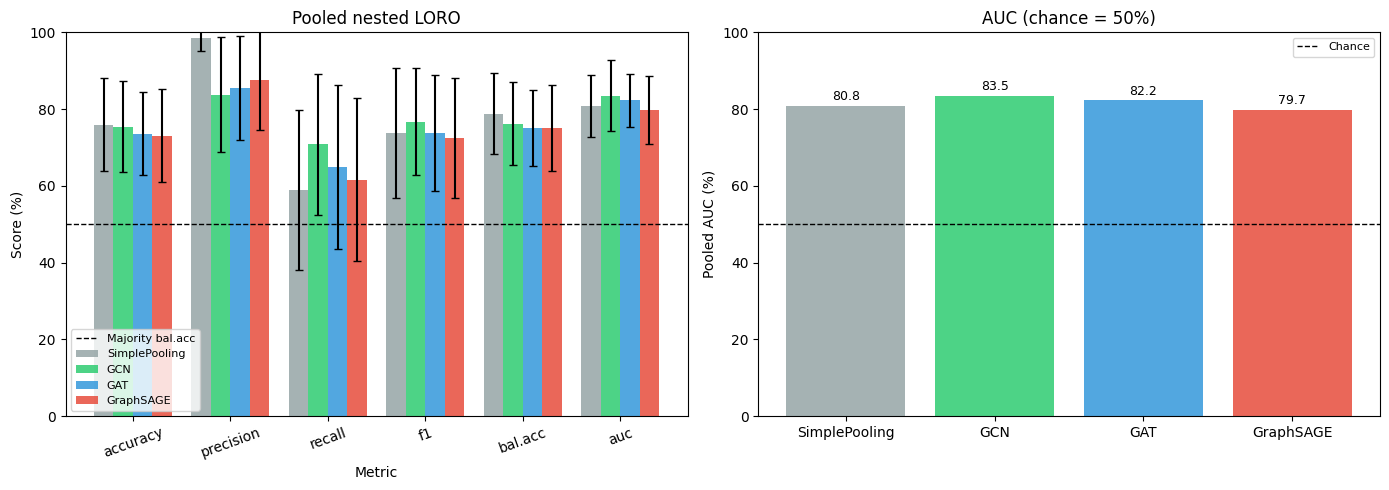

In [17]:
# Visualization
if len(all_model_results) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    model_names = list(all_model_results.keys())
    colors = ['#95a5a6', '#2ecc71', '#3498db', '#e74c3c']

    x = np.arange(len(METRICS))
    width = 0.8 / max(len(model_names), 1)

    for i, name in enumerate(model_names):
        res = all_model_results[name]
        means = [res[m]['pooled'] * 100 for m in METRICS]
        # Error bars show the per-fold spread around the pooled value, which is a
        # dispersion diagnostic - the bar height itself is the pooled metric.
        stds = [res[m]['fold_std'] * 100 for m in METRICS]
        axes[0].bar(x + i * width, means, width, yerr=stds, label=name,
                    color=colors[i % len(colors)], alpha=0.85, capsize=3)

    maj = all_model_results[model_names[0]]['_majority']
    axes[0].axhline(maj['balanced_accuracy'] * 100, color='k', linestyle='--',
                    linewidth=1, label='Majority bal.acc')
    axes[0].set_xlabel('Metric')
    axes[0].set_ylabel('Score (%)')
    axes[0].set_title('Pooled nested LORO')
    axes[0].set_xticks(x + width * (len(model_names) - 1) / 2)
    axes[0].set_xticklabels([m.replace('balanced_accuracy', 'bal.acc') for m in METRICS],
                            rotation=20)
    axes[0].legend(fontsize=8)
    axes[0].set_ylim(0, 100)

    # AUC is the metric least fooled by the class imbalance, so compare on it directly.
    auc_vals = [all_model_results[m]['auc']['pooled'] * 100 for m in model_names]
    bars = axes[1].bar(model_names, auc_vals, color=colors[:len(model_names)], alpha=0.85)
    axes[1].axhline(50, color='k', linestyle='--', linewidth=1, label='Chance')
    axes[1].set_ylabel('Pooled AUC (%)')
    axes[1].set_title('AUC (chance = 50%)')
    axes[1].set_ylim(0, 100)
    axes[1].legend(fontsize=8)

    for bar, v in zip(bars, auc_vals):
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
                     f'{v:.1f}', ha='center', fontsize=9)

    plt.tight_layout()
    plt.savefig('extension_data/gnn_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

In [18]:
# Save all results
import json

def convert_numpy(obj):
    if isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: convert_numpy(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_numpy(i) for i in obj]
    return obj

results_to_save = {
    'summary': all_model_results,
    'folds': all_fold_results,
    'config': {
        'num_epochs': NUM_EPOCHS,
        'learning_rate': LEARNING_RATE,
        'batch_size': BATCH_SIZE,
        'pos_weight': POS_WEIGHT,
        'hidden_dim': HIDDEN_DIM,
        'num_layers': NUM_LAYERS,
        'n_val_recipes': N_VAL_RECIPES,
        'seed': SEED,
        'combine': COMBINE,
        'feature_dim': FEATURE_DIM,
        'protocol': 'nested leave-one-recipe-out, epoch selected on validation loss',
    }
}

if 'ablation_results' in dir():
    results_to_save['projection_ablation'] = ablation_results

with open('extension_data/gnn_results.json', 'w') as f:
    json.dump(convert_numpy(results_to_save), f, indent=2)

print("Results saved to extension_data/gnn_results.json")

Results saved to extension_data/gnn_results.json


---
## 7b. Ablation: learnable projection vs fixed average

The spec asks for a **learnable projection** of the node features and the visual
features. The obvious cheaper alternative is the fixed `0.5*visual + 0.5*text` average.
This runs the best-performing architecture both ways on identical folds, identical
seeds and identical data, so the difference is attributable to the projection alone.

Reporting this as an ablation matters because the projection is not free: it adds
~198k parameters to a model trained on 383 graphs, and on a dataset this small extra
capacity is as likely to hurt as to help. The measured answer goes in the report either
way.

In [19]:
# Ablation: does the learnable projection actually beat the fixed average?
if PYG_AVAILABLE:
    ABLATION_MODEL = GraphSAGEClassifier
    ABLATION_NAME = 'GraphSAGE'

    ablation_results = {}
    for combine in ['average', 'projection']:
        print("\n" + "=" * 66)
        print(f"{ABLATION_NAME} with combiner = {combine!r}")
        print("=" * 66)

        _folds, _pooled = leave_one_recipe_out_gnn(
            ABLATION_MODEL,
            pyg_data,
            recipe_groups,
            input_dim=FEATURE_DIM,
            num_epochs=NUM_EPOCHS,
            lr=LEARNING_RATE,
            batch_size=BATCH_SIZE,
            pos_weight=POS_WEIGHT,
            n_val_recipes=N_VAL_RECIPES,
            seed=SEED,
            hidden_dim=HIDDEN_DIM,
            num_layers=NUM_LAYERS,
            combine=combine,
        )
        ablation_results[combine] = summarize_results(
            _folds, _pooled, f"{ABLATION_NAME} ({combine})", num_epochs=NUM_EPOCHS)

    print("\n" + "=" * 66)
    print("PROJECTION ABLATION")
    print("=" * 66)
    print(f"{'metric':<20}{'average':>12}{'projection':>13}{'delta':>10}")
    for m in ['f1', 'balanced_accuracy', 'auc']:
        a = ablation_results['average'][m]['pooled'] * 100
        p = ablation_results['projection'][m]['pooled'] * 100
        print(f"{m:<20}{a:>11.2f}%{p:>12.2f}%{p - a:>+9.2f}")
    print("\nA delta within a couple of points is noise at n=383 with 24 folds;")
    print("report it as such rather than as evidence the projection helps.")


GraphSAGE with combiner = 'average'

Nested leave-one-recipe-out over 24 recipes (4 held out for validation inside each fold)


Folds: 100%|██████████| 24/24 [02:05<00:00,  5.21s/it]



GraphSAGE (average)  -  pooled over 24 folds, 383 recordings
metric                     model    majority
accuracy                  69.97%      57.18%
precision                 77.37%           -
recall                    67.12%           -
f1                        71.88%      72.76%
balanced_accuracy         70.45%      50.00%
auc                       76.28%      50.00%

Per-fold spread (diagnostic, not the headline):
  accuracy            69.50% +/- 11.07%
  precision           82.61% +/- 17.14%
  recall              65.99% +/- 21.52%
  f1                  69.00% +/- 13.96%
  balanced_accuracy   70.28% +/- 9.74%
  auc                 80.10% +/- 10.38%

Selected epoch: mean 4.1 of 50, median 4, max 7
  -> validation loss bottoms out within the first few epochs; it still beats the baseline comfortably, so this is fast convergence followed by overfitting, not failure to learn.
Positive rate: 49.61% (true: 57.18%)

GraphSAGE with combiner = 'projection'

Nested leave-one-recipe-out ov

Folds: 100%|██████████| 24/24 [02:16<00:00,  5.70s/it]


GraphSAGE (projection)  -  pooled over 24 folds, 383 recordings
metric                     model    majority
accuracy                  72.32%      57.18%
precision                 86.93%           -
recall                    60.73%           -
f1                        71.51%      72.76%
balanced_accuracy         74.27%      50.00%
auc                       79.13%      50.00%

Per-fold spread (diagnostic, not the headline):
  accuracy            71.93% +/- 11.63%
  precision           90.32% +/- 13.31%
  recall              60.09% +/- 20.55%
  f1                  68.92% +/- 15.07%
  balanced_accuracy   73.48% +/- 10.84%
  auc                 83.16% +/- 8.68%

Selected epoch: mean 2.2 of 50, median 2, max 6
  -> validation loss bottoms out within the first few epochs; it still beats the baseline comfortably, so this is fast convergence followed by overfitting, not failure to learn.
Positive rate: 39.95% (true: 57.18%)

PROJECTION ABLATION
metric                   average   projection  

## Summary

**Substep 4: GNN classification of the realized task graph.**

1. Converted realized task graphs to PyTorch Geometric format, keeping visual and text
   node features separate as `[visual | text | matched_flag]`
2. Implemented the learnable projection as the first module of each model, trained
   end-to-end by the classification loss, with a fixed `0.5/0.5` average retained as a
   parameter-free control
3. Compared SimplePooling (no edges), GCN, GAT and GraphSAGE
4. Evaluated with nested leave-one-recipe-out cross-validation, selecting the epoch on a
   held-out validation split of four recipes
5. Ran a depth study under the same protocol

### Reading the results

- **Use balanced accuracy and AUC rather than F1.** 57% of recordings are labelled
  incorrect, so a model that predicts "incorrect" everywhere already scores a high F1.
  The majority baseline is printed in the same table for this reason.
- **Check `sel.epoch`.** Validation loss bottoming out within the first few epochs means
  the model converges almost immediately; whether that constitutes failure depends on
  whether it beats the baseline, which the summary reports alongside it.
- **Compare against SimplePooling.** It receives identical node features but no edges, so
  any claim that the task-graph structure contributes has to appear as a gap over it.
- **Treat small differences as noise.** Repeated runs of an identical configuration differ
  by roughly 0.4-0.7 AUC points here, because the graph convolutions use non-deterministic
  CUDA scatter operations. Substep 2 measured around 4 AUC points of variation on its
  smaller 119-recording subset.

### Relation to the other substeps

The node features consumed here are built on the EgoVLP video-text alignment measured in
Substep 3, where video-to-text retrieval of a step's own description reaches 27.31% top-1
against a 7.15% chance rate. That alignment is genuine but weak, and it upper-bounds what
the matching step can contribute.

---
## 8. GNN depth and oversmoothing

Oversmoothing is the failure mode in which stacking graph convolution layers drives every
node representation toward the same value, so a deep GNN loses the ability to distinguish
nodes. Task graphs here hold roughly 12-14 nodes in a near-chain, so a receptive field of
four or more hops already spans most of the graph and the effect should be observable.

Each depth is evaluated with the same nested leave-one-recipe-out protocol used for every
other result in this notebook, so depths are comparable both to each other and to the
headline table. In particular the epoch is selected on a held-out validation split rather
than on the test fold: tracking the best test score across epochs would report the most
favourable epoch out of many rather than the score of a model chosen without access to the
answers, which inflates results by roughly ten to twenty points at this sample size.

In [20]:
# ==============================================================================
# GNN DEPTH STUDY  (nested LORO - no test-set selection)
# ==============================================================================
# Runtime warning: this is len(DEPTH_CONFIGS) x len(models) full nested-LORO runs.
# With 4 depths x 3 models x 24 folds it is the most expensive cell in the notebook.
# DEPTH_EPOCHS is lowered from NUM_EPOCHS to keep it tractable; the depths are still
# compared against each other under identical settings, which is what the study needs.

if PYG_AVAILABLE and len(pyg_data) > 0:

    DEPTH_CONFIGS = [2, 4, 6, 8]
    DEPTH_EPOCHS = 30
    DEPTH_METRIC = 'auc'      # least distorted by the 61/39 class imbalance

    depth_models = [('GCN', GCNClassifier),
                    ('GAT', GATClassifier),
                    ('GraphSAGE', GraphSAGEClassifier)]

    oversmoothing_results = {name: {} for name, _ in depth_models}

    print("=" * 70)
    print("GNN DEPTH STUDY - nested leave-one-recipe-out")
    print(f"Depths: {DEPTH_CONFIGS}   epochs: {DEPTH_EPOCHS}   metric: {DEPTH_METRIC}")
    print("=" * 70)

    for model_name, ModelClass in depth_models:
        print(f"\n>>> {model_name} <<<")

        for num_layers in DEPTH_CONFIGS:
            kwargs = dict(hidden_dim=HIDDEN_DIM, num_layers=num_layers,
                          dropout=0.3, combine=COMBINE)
            if model_name == 'GAT':
                kwargs['heads'] = 4

            folds, pooled = leave_one_recipe_out_gnn(
                ModelClass, pyg_data, recipe_groups,
                input_dim=FEATURE_DIM,
                num_epochs=DEPTH_EPOCHS,
                lr=LEARNING_RATE,
                batch_size=BATCH_SIZE,
                pos_weight=POS_WEIGHT,
                n_val_recipes=N_VAL_RECIPES,
                seed=SEED,
                verbose=False,
                **kwargs
            )

            binary = (pooled['probs'] >= 0.5).astype(int)
            scores = {
                'auc': roc_auc_score(pooled['labels'], pooled['probs']),
                'f1': f1_score(pooled['labels'], binary, zero_division=0),
                'balanced_accuracy': balanced_accuracy_score(pooled['labels'], binary),
            }
            oversmoothing_results[model_name][num_layers] = scores

            print(f"  {num_layers} layers: AUC {scores['auc']*100:.2f}%  "
                  f"bal.acc {scores['balanced_accuracy']*100:.2f}%  "
                  f"F1 {scores['f1']*100:.2f}%")

    print("\n" + "=" * 70)
    print(f"DEPTH SUMMARY  (pooled {DEPTH_METRIC.upper()}, %)")
    print("=" * 70)
    header = f"{'Model':<12}" + "".join(f"{str(d) + ' layers':>12}" for d in DEPTH_CONFIGS)
    print(header)
    print("-" * len(header))
    for model_name in oversmoothing_results:
        row = f"{model_name:<12}"
        for d in DEPTH_CONFIGS:
            row += f"{oversmoothing_results[model_name][d][DEPTH_METRIC]*100:>11.2f}%"
        print(row)
else:
    print("PyTorch Geometric unavailable or no data - skipping depth study.")

GNN DEPTH STUDY - nested leave-one-recipe-out
Depths: [2, 4, 6, 8]   epochs: 30   metric: auc

>>> GCN <<<


Folds: 100%|██████████| 24/24 [01:18<00:00,  3.25s/it]


  2 layers: AUC 82.21%  bal.acc 74.72%  F1 75.12%


Folds: 100%|██████████| 24/24 [01:41<00:00,  4.24s/it]


  4 layers: AUC 80.94%  bal.acc 73.35%  F1 72.49%


...

  4 layers: AUC 81.75%  bal.acc 76.93%  F1 74.93%


Folds: 100%|██████████| 24/24 [01:46<00:00,  4.44s/it]


  6 layers: AUC 81.37%  bal.acc 75.33%  F1 73.35%


Folds: 100%|██████████| 24/24 [02:03<00:00,  5.16s/it]

  8 layers: AUC 81.89%  bal.acc 78.00%  F1 74.52%

DEPTH SUMMARY  (pooled AUC, %)
Model           2 layers    4 layers    6 layers    8 layers
------------------------------------------------------------
GCN               82.21%      80.94%      79.94%      78.95%
GAT               82.07%      83.29%      81.28%      82.60%
GraphSAGE         83.27%      81.75%      81.37%      81.89%


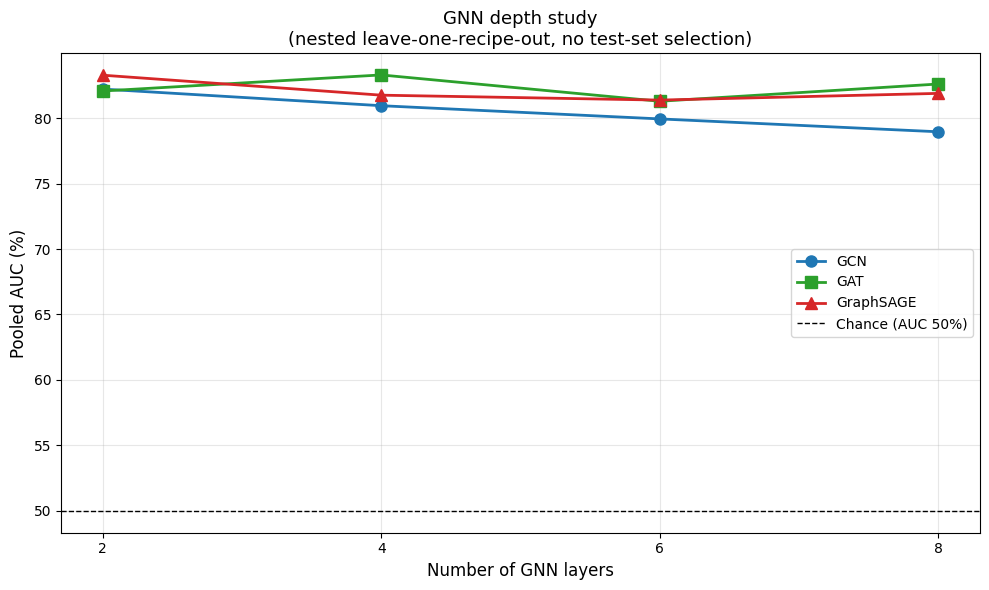


>>> READING THIS PLOT <<<
  GCN        : best at 2 layers; 2->8 layers degrades with depth (-3.26 points of AUC)
  GAT        : best at 4 layers; 2->8 layers is flat in depth (+0.53 points of AUC)
  GraphSAGE  : best at 2 layers; 2->8 layers is flat in depth (-1.39 points of AUC)

Oversmoothing is only demonstrated where the curve falls as depth grows.
A flat curve at these graph sizes is a real result too, and more likely to
mean the model is not using graph structure much in the first place -
compare against the SimplePooling baseline, which sees no edges at all.


In [21]:
# ==============================================================================
# VISUALIZATION: depth vs performance
# ==============================================================================
import matplotlib.pyplot as plt

if 'oversmoothing_results' in dir() and oversmoothing_results:
    fig, ax = plt.subplots(figsize=(10, 6))

    colors = {'GCN': 'tab:blue', 'GAT': 'tab:green', 'GraphSAGE': 'tab:red'}
    markers = {'GCN': 'o', 'GAT': 's', 'GraphSAGE': '^'}

    for model_name, results in oversmoothing_results.items():
        depths = sorted(results.keys())
        vals = [results[d][DEPTH_METRIC] * 100 for d in depths]
        ax.plot(depths, vals, marker=markers[model_name], color=colors[model_name],
                label=model_name, linewidth=2, markersize=8)

    ax.axhline(50, color='k', linestyle='--', linewidth=1, label='Chance (AUC 50%)')
    ax.set_xlabel('Number of GNN layers', fontsize=12)
    ax.set_ylabel(f'Pooled {DEPTH_METRIC.upper()} (%)', fontsize=12)
    ax.set_title('GNN depth study\n(nested leave-one-recipe-out, no test-set selection)',
                 fontsize=13)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(DEPTH_CONFIGS)

    plt.tight_layout()
    plt.savefig('extension_data/gnn_depth_study.png', dpi=150, bbox_inches='tight')
    plt.show()

    # State what the numbers show, rather than asserting oversmoothing regardless.
    print("\n>>> READING THIS PLOT <<<")
    for model_name, results in oversmoothing_results.items():
        depths = sorted(results.keys())
        vals = [results[d][DEPTH_METRIC] for d in depths]
        best_d = depths[int(np.argmax(vals))]
        change = (vals[-1] - vals[0]) * 100      # signed: negative means it got worse
        trend = ("degrades with depth" if change < -2 else
                 "improves with depth" if change > 2 else
                 "is flat in depth")
        print(f"  {model_name:<11}: best at {best_d} layers; "
              f"{depths[0]}->{depths[-1]} layers {trend} "
              f"({change:+.2f} points of {DEPTH_METRIC.upper()})")
    print("\nOversmoothing is only demonstrated where the curve falls as depth grows.")
    print("A flat curve at these graph sizes is a real result too, and more likely to")
    print("mean the model is not using graph structure much in the first place -")
    print("compare against the SimplePooling baseline, which sees no edges at all.")
else:
    print("Run the depth study first")